In [137]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

TEMP_COLOR = '#d95f02'
PROCESS_COLORS = {
    'tendtot': 'black',
    'dyntot': '#c70024',
    'phystot': '#0066cc',
}
PROCESS_LABELS = {
    'tendtot': 'Total',
    'dyntot': 'Dynamical',
    'phystot': 'Physical',
}


# General Setup

In [138]:
# Toy model calendar
days_per_year = 365
n_years = 44
start_year = 1980
year_start_month = 12

# No-leap calendar
month_lengths = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
month_names = np.array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

year_start_day = month_lengths[:year_start_month - 1].sum()
year_labels = np.arange(start_year, start_year + n_years)
years_ext = np.arange(n_years + 1)
days = np.arange(days_per_year)

calendar_days = (days + year_start_day) % days_per_year
month_order = np.r_[year_start_month - 1:12, 0:year_start_month - 1]
month_labels = month_names[month_order]
month_ticks = np.r_[0, np.cumsum(month_lengths[month_order])[:-1]]

analysis_month = np.repeat(month_order, month_lengths[month_order])
season_days = {
    'DJF': np.isin(analysis_month, [11, 0, 1]),
    'MAM': np.isin(analysis_month, [2, 3, 4]),
    'JJA': np.isin(analysis_month, [5, 6, 7]),
    'SON': np.isin(analysis_month, [8, 9, 10]),
}

In [139]:
# Toy model warming with seasonal cycle
def calendar_day_from_analysis_day(day):
    return (day + year_start_day) % days_per_year

def seasonal_cycle(day):
    calendar_day = calendar_day_from_analysis_day(day)
    return -10*np.cos(2*np.pi*calendar_day / days_per_year) + 10

def warming_rate(day, base=0.3, amp=0.1, peak_day_calendar=200):
    calendar_day = calendar_day_from_analysis_day(day)
    return base + amp*np.cos(2*np.pi*(calendar_day - peak_day_calendar) / days_per_year)

def process_contrast(day, mean=0.06, annual_amp=0.34, shoulder_amp=0.24, peak_day_calendar=190):
    calendar_day = calendar_day_from_analysis_day(day)
    phase = 2*np.pi*(calendar_day - peak_day_calendar) / days_per_year
    return mean + annual_amp*np.cos(phase) - shoulder_amp*np.sin(phase)

def dyntot_change_rate(day, mean=0.0018, semiannual_amp=0.0014, peak_day_calendar=20):
    calendar_day = calendar_day_from_analysis_day(day)
    phase = 4*np.pi*(calendar_day - peak_day_calendar) / days_per_year
    return mean + semiannual_amp*np.cos(phase)

# def warming_rate(day, base=0.1, amp=0.3, peak_day_calendar=200):
#     calendar_day = calendar_day_from_analysis_day(day)

#     rate = np.full_like(calendar_day, base, dtype='float32')

#     # DJF
#     rate[(calendar_day >= 334) | (calendar_day < 59)] = base - 1/3*amp

#     # MAM and SON
#     rate[(calendar_day >= 59) & (calendar_day < 151)] = base - 1/3*amp
#     rate[(calendar_day >= 243) & (calendar_day < 334)] = base -1/3*amp

#     # JJA
#     rate[(calendar_day >= 151) & (calendar_day < 243)] = base + amp

#     return rate

year_grid, day_grid = np.meshgrid(years_ext, days, indexing='ij')
time_grid = year_grid + day_grid / days_per_year

S_y_d = seasonal_cycle(day_grid)
a_y_d = warming_rate(day_grid)

T_ext = S_y_d + a_y_d*time_grid

# Analysis years only
T_y_d = T_ext[:n_years]
T_ref_y_d = S_y_d[:n_years]

# Forward daily tendency, including the final day to first day step of the next analysis year
D_y_d = T_ext[:n_years, 1:] - T_ext[:n_years, :-1]
D_last = T_ext[1:n_years + 1, 0] - T_ext[:n_years, -1]
D_y_d = np.concatenate([D_y_d, D_last[:, None]], axis=1)

# Stationary reference tendency from seasonal cycle only
D_ref_y_d = S_y_d[:n_years, 1:] - S_y_d[:n_years, :-1]
D_ref_last = S_y_d[1:n_years + 1, 0] - S_y_d[:n_years, -1]
D_ref_y_d = np.concatenate([D_ref_y_d, D_ref_last[:, None]], axis=1)

# Toy split of the total tendency into two smooth process tendencies.
# phystot warms overall but cools in DJF/SON; dyntot is the residual opposite.
# The time-varying part is assigned mostly to dyntot: more winter heating
# and less summer cooling, compensated by phystot so the total still closes.
process_contrast_y_d = process_contrast(day_grid[:n_years])
dyntot_change_y_d = dyntot_change_rate(day_grid[:n_years]) * time_grid[:n_years]
D_phystot_y_d = 0.5*D_y_d + process_contrast_y_d - dyntot_change_y_d
D_dyntot_y_d = 0.5*D_y_d - process_contrast_y_d + dyntot_change_y_d

D_process_y_d = {
    'tendtot': D_y_d,
    'phystot': D_phystot_y_d,
    'dyntot': D_dyntot_y_d,
}

np.testing.assert_allclose(D_phystot_y_d + D_dyntot_y_d, D_y_d, atol=1e-12)


# Some sketch plots of toy model

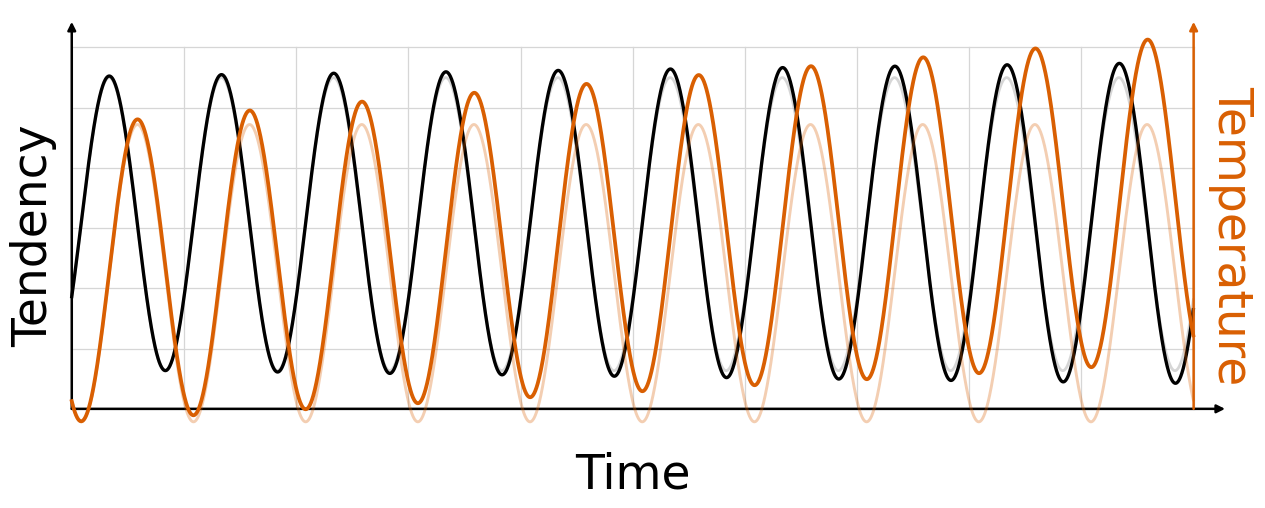

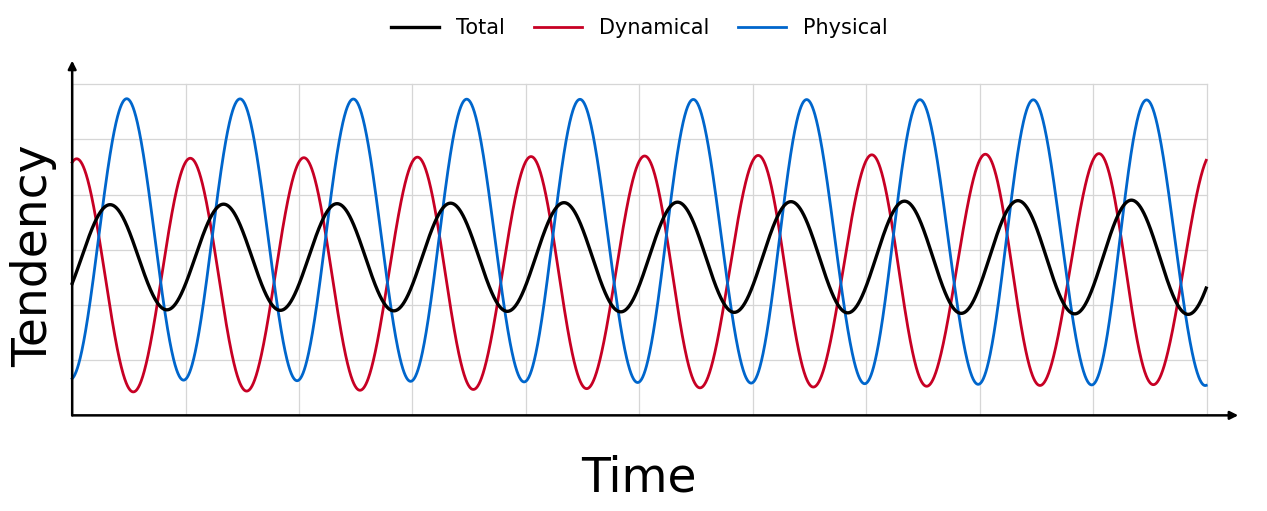

In [140]:
# %%
# Sketch from the same toy-model structure.
# Plot 1: temperature with total tendency. Plot 2: total tendency with processes.

n_years_sketch = 10
years_ext_sketch = np.arange(n_years_sketch + 1)
years_sketch = np.arange(n_years_sketch)

year_grid_sketch, day_grid_sketch = np.meshgrid(years_ext_sketch, days, indexing='ij')
time_grid_sketch = year_grid_sketch + day_grid_sketch / days_per_year

S_y_d_sketch = seasonal_cycle(day_grid_sketch)
a_y_d_sketch = warming_rate(day_grid_sketch, base=0.50, amp=0.10, peak_day_calendar=200)

T_ext_sketch = S_y_d_sketch + a_y_d_sketch * time_grid_sketch
T_y_d_sketch = T_ext_sketch[:n_years_sketch]
T_ref_y_d_sketch = S_y_d_sketch[:n_years_sketch]

D_y_d_sketch = T_ext_sketch[:n_years_sketch, 1:] - T_ext_sketch[:n_years_sketch, :-1]
D_last_sketch = T_ext_sketch[1:n_years_sketch + 1, 0] - T_ext_sketch[:n_years_sketch, -1]
D_y_d_sketch = np.concatenate([D_y_d_sketch, D_last_sketch[:, None]], axis=1)

D_ref_y_d_sketch = S_y_d_sketch[:n_years_sketch, 1:] - S_y_d_sketch[:n_years_sketch, :-1]
D_ref_last_sketch = S_y_d_sketch[1:n_years_sketch + 1, 0] - S_y_d_sketch[:n_years_sketch, -1]
D_ref_y_d_sketch = np.concatenate([D_ref_y_d_sketch, D_ref_last_sketch[:, None]], axis=1)

process_contrast_sketch_y_d = process_contrast(day_grid_sketch[:n_years_sketch])
dyntot_change_sketch_y_d = (
    dyntot_change_rate(day_grid_sketch[:n_years_sketch])
    * time_grid_sketch[:n_years_sketch]
)
D_phystot_sketch_y_d = 0.5*D_y_d_sketch + process_contrast_sketch_y_d - dyntot_change_sketch_y_d
D_dyntot_sketch_y_d = 0.5*D_y_d_sketch - process_contrast_sketch_y_d + dyntot_change_sketch_y_d
np.testing.assert_allclose(D_phystot_sketch_y_d + D_dyntot_sketch_y_d, D_y_d_sketch, atol=1e-12)

x_sketch = (years_sketch[:, None] + days[None, :] / days_per_year).ravel()
T_plot_sketch = T_y_d_sketch.ravel()
T_ref_plot_sketch = T_ref_y_d_sketch.ravel()
D_plot_sketch = D_y_d_sketch.ravel()
D_ref_plot_sketch = D_ref_y_d_sketch.ravel()
D_phystot_plot_sketch = D_phystot_sketch_y_d.ravel()
D_dyntot_plot_sketch = D_dyntot_sketch_y_d.ravel()

x0, x1 = 0.0, n_years_sketch
axis_zorder = 100
label_kw = dict(fontsize=34)
arrow_kw_x = dict(arrowstyle='-|>', lw=1.8, color='black', shrinkA=0, shrinkB=0, mutation_scale=12)
arrow_kw_left = dict(arrowstyle='-|>', lw=1.8, color='black', shrinkA=0, shrinkB=0, mutation_scale=12)
arrow_kw_right = dict(arrowstyle='-|>', lw=1.8, color=TEMP_COLOR, shrinkA=0, shrinkB=0, mutation_scale=12)

fig, ax_tend = plt.subplots(figsize=(12.8, 5.2))
ax_temp = ax_tend.twinx()

ax_temp.plot(x_sketch, T_ref_plot_sketch, lw=2.1, color=TEMP_COLOR, alpha=0.30, zorder=3)
ax_temp.plot(x_sketch, T_plot_sketch, lw=2.7, color=TEMP_COLOR, zorder=4)
ax_tend.plot(x_sketch, D_ref_plot_sketch, lw=2.0, color='0.55', alpha=0.35, zorder=2)
ax_tend.plot(x_sketch, D_plot_sketch, lw=2.4, color=PROCESS_COLORS['tendtot'], zorder=5)

y0_temp = min(T_ref_plot_sketch.min(), T_plot_sketch.min())
y1_temp = max(T_ref_plot_sketch.max(), T_plot_sketch.max())
yr_temp = y1_temp - y0_temp
ax_temp.set_ylim(y0_temp - 0.10*yr_temp, y1_temp + 0.08*yr_temp)

y0_tend = min(D_ref_plot_sketch.min(), D_plot_sketch.min())
y1_tend = max(D_ref_plot_sketch.max(), D_plot_sketch.max())
yr_tend = y1_tend - y0_tend
y_grid0 = y0_tend - 0.08*yr_tend
y_grid1 = y1_tend + 0.05*yr_tend

ax_tend.set_xlim(-0.45, x1 + 0.45)
ax_tend.set_ylim(y_grid0 - 0.16*yr_tend, y_grid1 + 0.12*yr_tend)

for ax in [ax_tend, ax_temp]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

for xx in np.arange(x0, x1 + 1, 1):
    ax_tend.plot([xx, xx], [y_grid0, y_grid1], color='0.84', lw=0.9, zorder=0)
for yy in np.linspace(y_grid0, y_grid1, 7):
    ax_tend.plot([x0, x1], [yy, yy], color='0.84', lw=0.9, zorder=0)

ax_tend.annotate(
    '', xy=(x1 + 0.28, y_grid0), xytext=(x0, y_grid0),
    arrowprops=arrow_kw_x, annotation_clip=False, zorder=axis_zorder,
)
ax_tend.annotate(
    '', xy=(x0, y_grid1 + 0.08*yr_tend), xytext=(x0, y_grid0),
    arrowprops=arrow_kw_left, annotation_clip=False, zorder=axis_zorder + 1,
)

def left_y_to_right_y(y_left):
    y_disp = ax_tend.transData.transform((x0, y_left))[1]
    return ax_temp.transData.inverted().transform((x0, y_disp))[1]

y_right0 = left_y_to_right_y(y_grid0)
y_right1 = left_y_to_right_y(y_grid1 + 0.08*yr_tend)
ax_temp.annotate(
    '', xy=(x1, y_right1), xytext=(x1, y_right0),
    arrowprops=arrow_kw_right, annotation_clip=False, zorder=axis_zorder + 2,
)

ax_tend.text(0.5, 0.02, 'Time', ha='center', va='top', transform=ax_tend.transAxes, **label_kw)
ax_tend.text(0.01, 0.50, 'Tendency', ha='center', va='center', rotation=90,
             color='black', transform=ax_tend.transAxes, **label_kw)
ax_tend.text(0.99, 0.50, 'Temperature', ha='center', va='center', rotation=270,
             color=TEMP_COLOR, transform=ax_tend.transAxes, **label_kw)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12.8, 5.2))

ax.plot(x_sketch, D_plot_sketch, lw=2.4, color=PROCESS_COLORS['tendtot'], label=PROCESS_LABELS['tendtot'], zorder=5)
ax.plot(x_sketch, D_dyntot_plot_sketch, lw=2.0, color=PROCESS_COLORS['dyntot'], label=PROCESS_LABELS['dyntot'], zorder=4)
ax.plot(x_sketch, D_phystot_plot_sketch, lw=2.0, color=PROCESS_COLORS['phystot'], label=PROCESS_LABELS['phystot'], zorder=4)

y0 = min(D_plot_sketch.min(), D_dyntot_plot_sketch.min(), D_phystot_plot_sketch.min())
y1 = max(D_plot_sketch.max(), D_dyntot_plot_sketch.max(), D_phystot_plot_sketch.max())
yr = y1 - y0
y_grid0 = y0 - 0.08*yr
y_grid1 = y1 + 0.05*yr

ax.set_xlim(-0.45, x1 + 0.45)
ax.set_ylim(y_grid0 - 0.16*yr, y_grid1 + 0.12*yr)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for xx in np.arange(x0, x1 + 1, 1):
    ax.plot([xx, xx], [y_grid0, y_grid1], color='0.84', lw=0.9, zorder=0)
for yy in np.linspace(y_grid0, y_grid1, 7):
    ax.plot([x0, x1], [yy, yy], color='0.84', lw=0.9, zorder=0)

ax.annotate(
    '', xy=(x1 + 0.28, y_grid0), xytext=(x0, y_grid0),
    arrowprops=arrow_kw_x, annotation_clip=False, zorder=axis_zorder,
)
ax.annotate(
    '', xy=(x0, y_grid1 + 0.08*yr), xytext=(x0, y_grid0),
    arrowprops=arrow_kw_left, annotation_clip=False, zorder=axis_zorder + 1,
)

ax.text(0.5, 0.02, 'Time', ha='center', va='top', transform=ax.transAxes, **label_kw)
ax.text(0.01, 0.50, 'Tendency', ha='center', va='center', rotation=90,
        color='black', transform=ax.transAxes, **label_kw)
ax.legend(
    loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3,
    frameon=False, fontsize=15, columnspacing=1.4, handlelength=2.3,
)

plt.tight_layout()
plt.show()


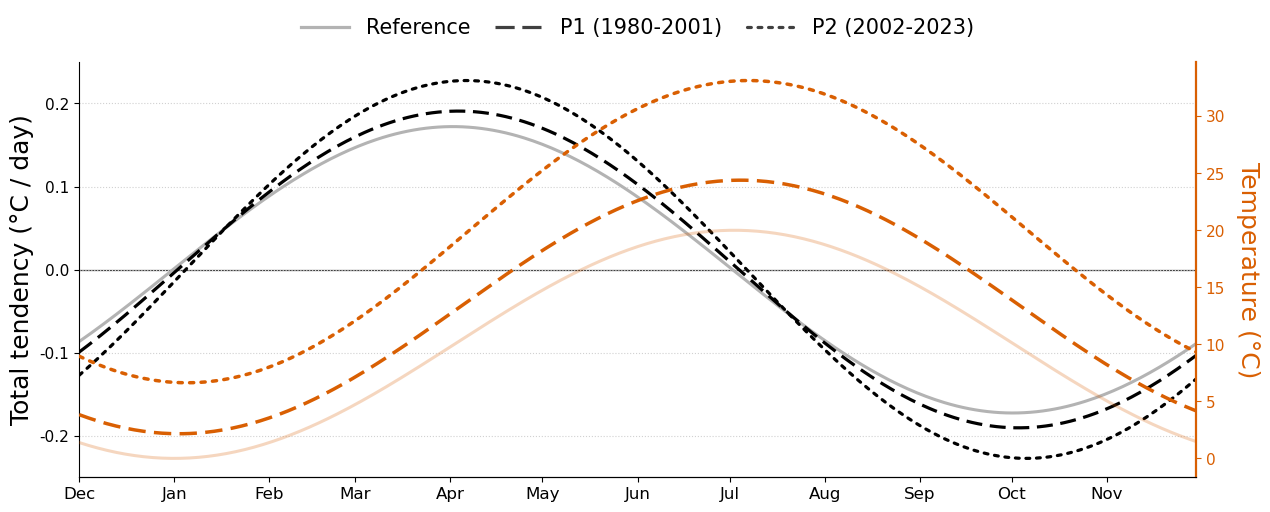

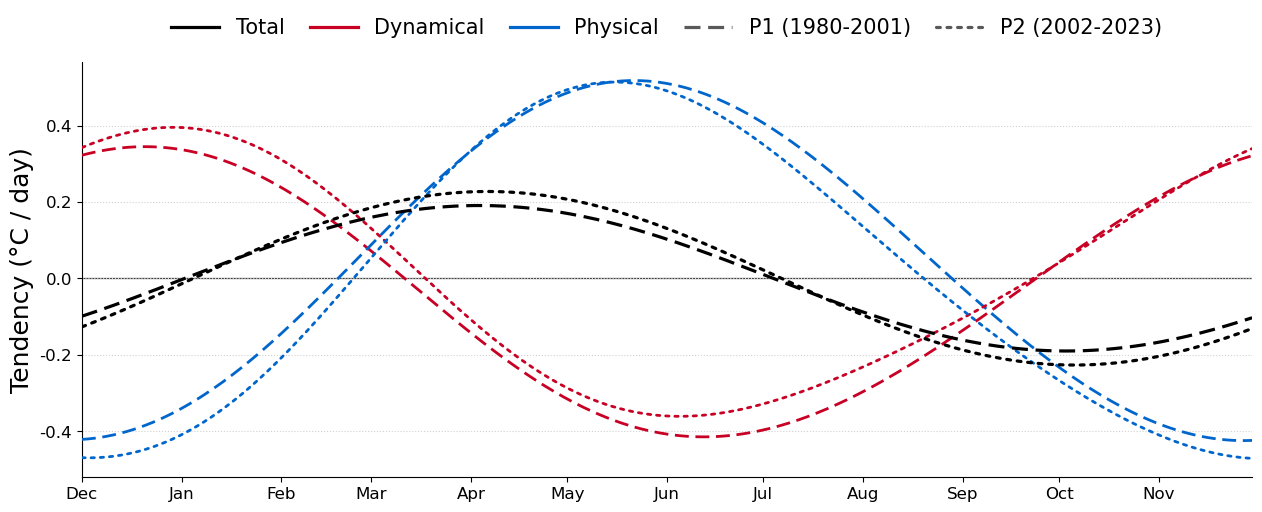

In [141]:
# %%
# Climatological calendar-day curves for the actual toy model.
# Plot 1: temperature with total tendency. Plot 2: total tendency with processes.

# Period split
L = n_years // 2

periods = {
    'P1': [year_labels[0], year_labels[L - 1]],
    'P2': [year_labels[L], year_labels[-1]],
}
period_labels = {
    period: f'{period} ({years[0]}-{years[1]})'
    for period, years in periods.items()
}

P1 = slice(0, L)
P2 = slice(L, n_years)
processes = ['dyntot', 'phystot']

# Calendar-day climatologies
T_P1 = T_y_d[P1].mean(axis=0)
T_P2 = T_y_d[P2].mean(axis=0)
T_ref = T_ref_y_d.mean(axis=0)

D_P1 = D_y_d[P1].mean(axis=0)
D_P2 = D_y_d[P2].mean(axis=0)
D_ref = D_ref_y_d.mean(axis=0)

D_process_P1 = {
    process: D_process_y_d[process][P1].mean(axis=0)
    for process in processes
}
D_process_P2 = {
    process: D_process_y_d[process][P2].mean(axis=0)
    for process in processes
}
np.testing.assert_allclose(D_process_P1['dyntot'] + D_process_P1['phystot'], D_P1, atol=1e-12)
np.testing.assert_allclose(D_process_P2['dyntot'] + D_process_P2['phystot'], D_P2, atol=1e-12)

fig, ax_tend = plt.subplots(figsize=(12.8, 5.2))
ax_temp = ax_tend.twinx()

# Total tendency, left axis
ax_tend.plot(days, D_ref, color='0.70', lw=2.2, zorder=2)
ax_tend.plot(days, D_P1, color='black', lw=2.3, ls='--', dashes=(5.0, 2.4), zorder=4)
ax_tend.plot(days, D_P2, color='black', lw=2.3, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', zorder=5)

# Temperature, right axis
ax_temp.plot(days, T_ref, color=TEMP_COLOR, lw=2.2, alpha=0.25, zorder=2)
ax_temp.plot(days, T_P1, color=TEMP_COLOR, lw=2.5, ls='--', dashes=(5.0, 2.4), zorder=4)
ax_temp.plot(days, T_P2, color=TEMP_COLOR, lw=2.5, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', zorder=5)

# Axes styling
ax_tend.axhline(0, color='0.25', lw=0.9, zorder=1)
ax_tend.grid(axis='y', color='0.82', lw=0.8, linestyle=':', zorder=0)

ax_tend.set_xlim(days[0], days[-1])
ax_tend.set_xticks(month_ticks)
ax_tend.set_xticklabels(month_labels, fontsize=12)

ax_tend.set_ylabel('Total tendency (°C / day)', fontsize=18, color='black')
ax_temp.set_ylabel('Temperature (°C)', fontsize=18, color=TEMP_COLOR, rotation=270, labelpad=25)

ax_tend.tick_params(axis='y', labelsize=11, colors='black')
ax_temp.tick_params(axis='y', labelsize=11, colors=TEMP_COLOR)
ax_tend.tick_params(axis='x', labelsize=12)

for ax in [ax_tend, ax_temp]:
    ax.spines['top'].set_visible(False)

ax_tend.spines['right'].set_visible(False)
ax_temp.spines['left'].set_visible(False)
ax_temp.spines['right'].set_color(TEMP_COLOR)
ax_temp.spines['right'].set_linewidth(1.6)

handles = [
    plt.Line2D([0], [0], color='0.70', lw=2.3, label='Reference'),
    plt.Line2D([0], [0], color='0.25', lw=2.3, ls='--', dashes=(6.0, 2.4), label=period_labels['P1']),
    plt.Line2D([0], [0], color='0.25', lw=2.3, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', label=period_labels['P2']),
]

ax_tend.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False,
    fontsize=15,
    columnspacing=1.2,
    handlelength=2.3,
)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12.8, 5.2))

ax.plot(days, D_P1, color=PROCESS_COLORS['tendtot'], lw=2.3, ls='--', dashes=(5.0, 2.4), zorder=5)
ax.plot(days, D_P2, color=PROCESS_COLORS['tendtot'], lw=2.3, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', zorder=6)

for process in processes:
    ax.plot(
        days, D_process_P1[process],
        color=PROCESS_COLORS[process], lw=2.0, ls='--', dashes=(5.0, 2.4), zorder=3,
    )
    ax.plot(
        days, D_process_P2[process],
        color=PROCESS_COLORS[process], lw=2.0, ls=':', dashes=(1.2, 2.1),
        dash_capstyle='round', zorder=4,
    )

ax.axhline(0, color='0.25', lw=0.9, zorder=1)
ax.grid(axis='y', color='0.82', lw=0.8, linestyle=':', zorder=0)
ax.set_xlim(days[0], days[-1])
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, fontsize=12)
ax.set_ylabel('Tendency (°C / day)', fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles = [
    plt.Line2D([0], [0], color=PROCESS_COLORS['tendtot'], lw=2.3, label=PROCESS_LABELS['tendtot']),
    plt.Line2D([0], [0], color=PROCESS_COLORS['dyntot'], lw=2.3, label=PROCESS_LABELS['dyntot']),
    plt.Line2D([0], [0], color=PROCESS_COLORS['phystot'], lw=2.3, label=PROCESS_LABELS['phystot']),
    plt.Line2D([0], [0], color='0.35', lw=2.3, ls='--', dashes=(5.0, 2.4), label=period_labels['P1']),
    plt.Line2D([0], [0], color='0.35', lw=2.3, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', label=period_labels['P2']),
]
ax.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=5,
    frameon=False,
    fontsize=15,
    columnspacing=1.2,
    handlelength=2.3,
)

plt.tight_layout()
plt.show()


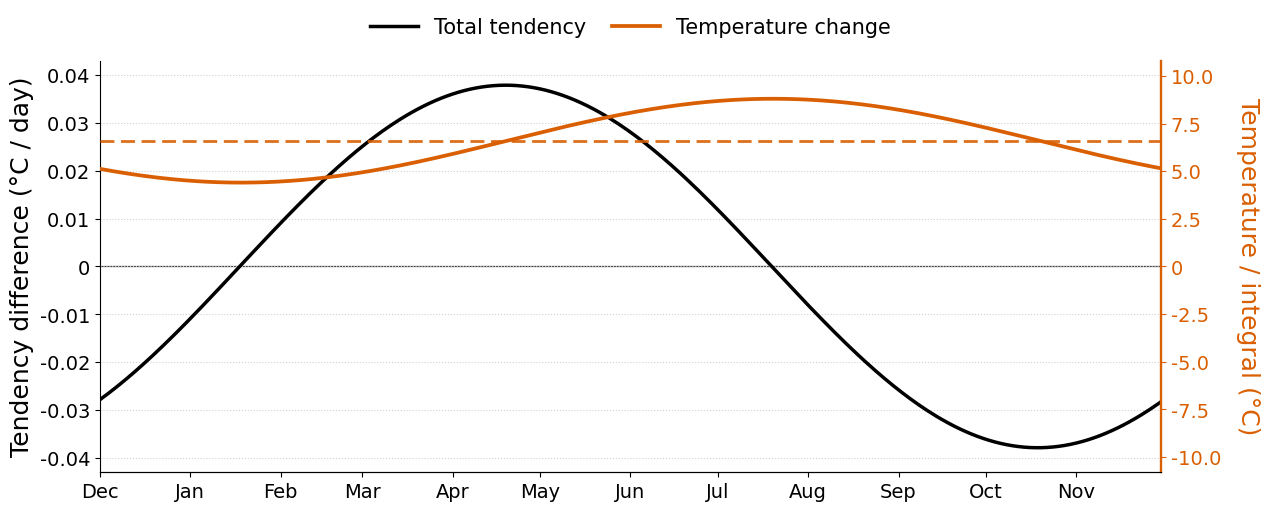

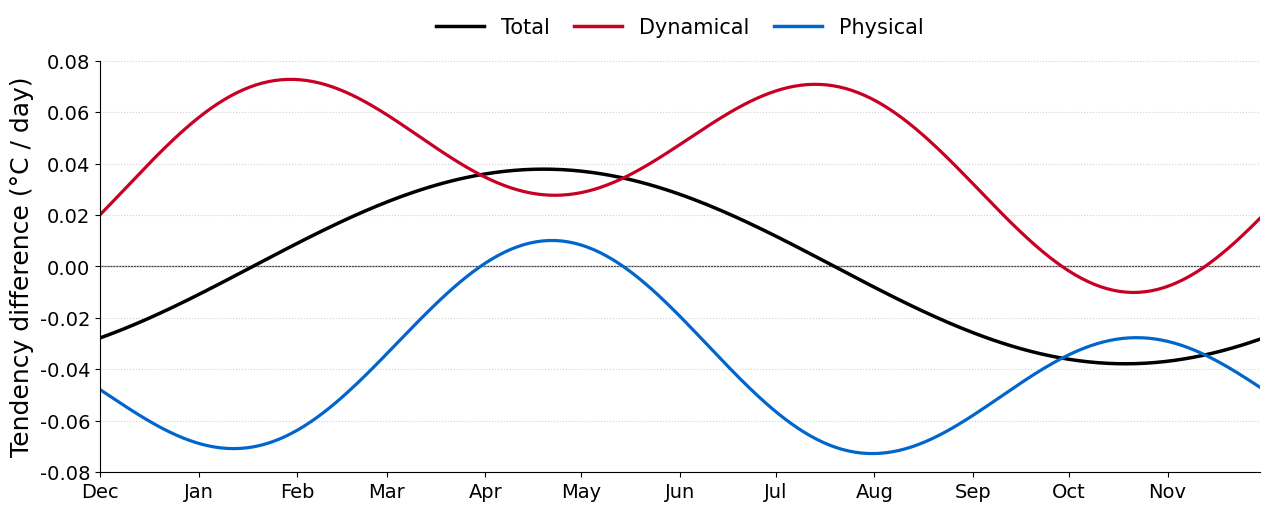

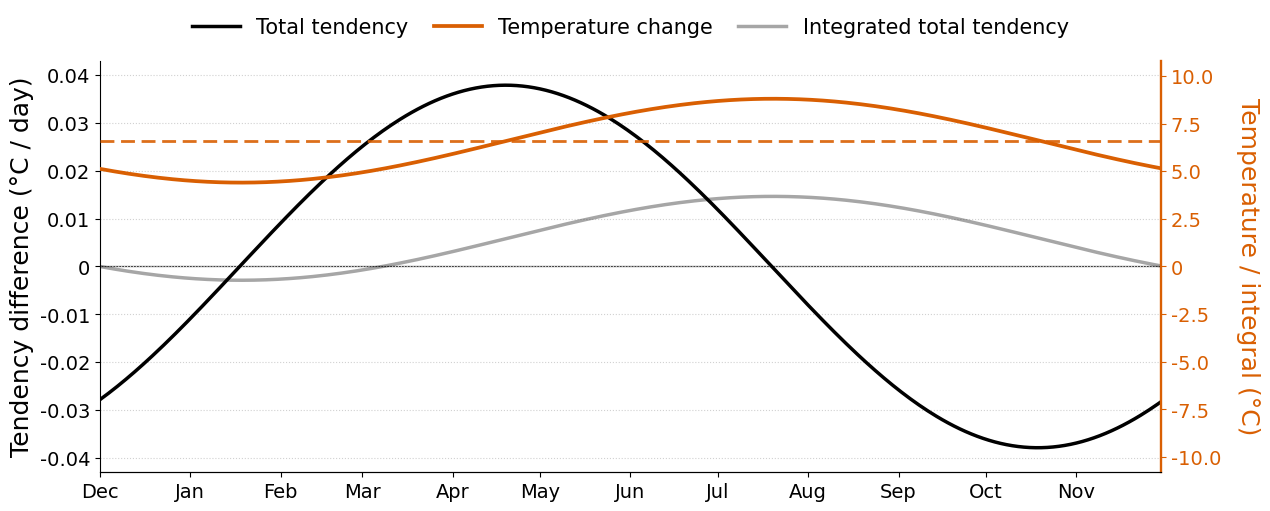

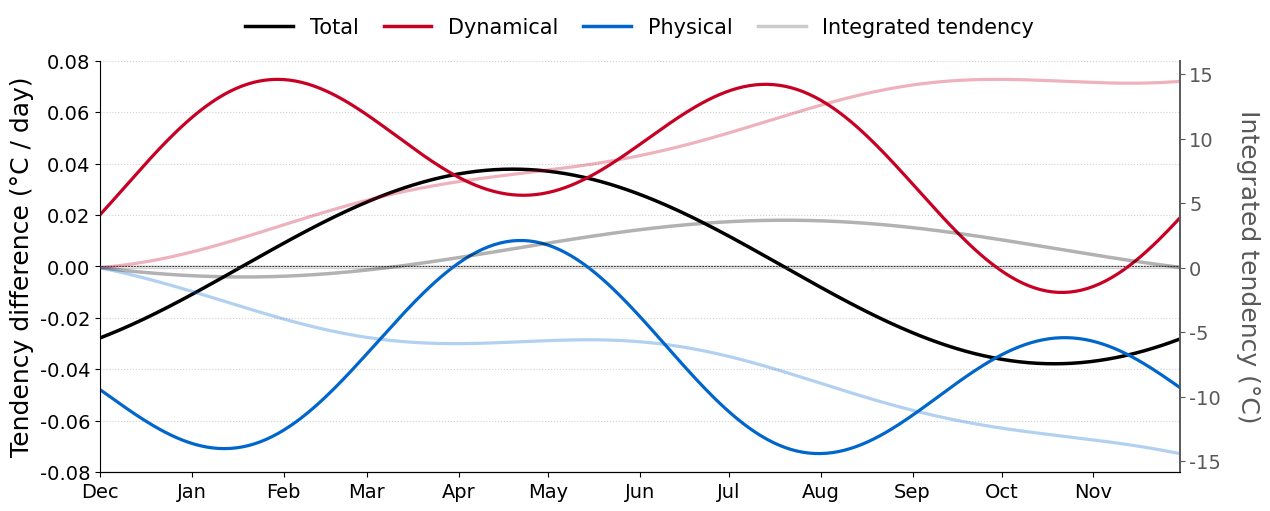

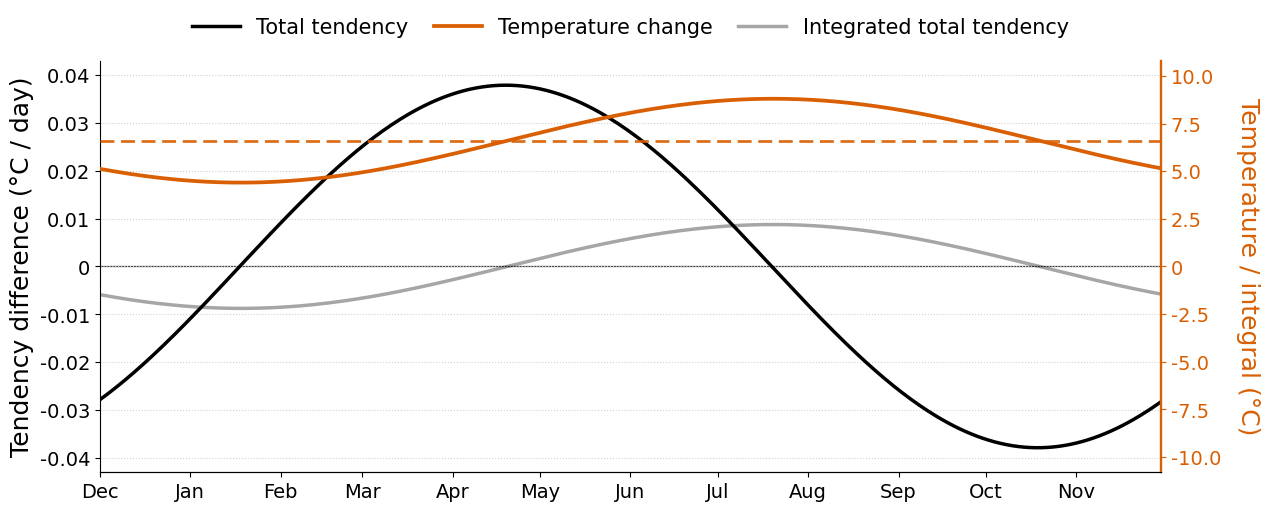

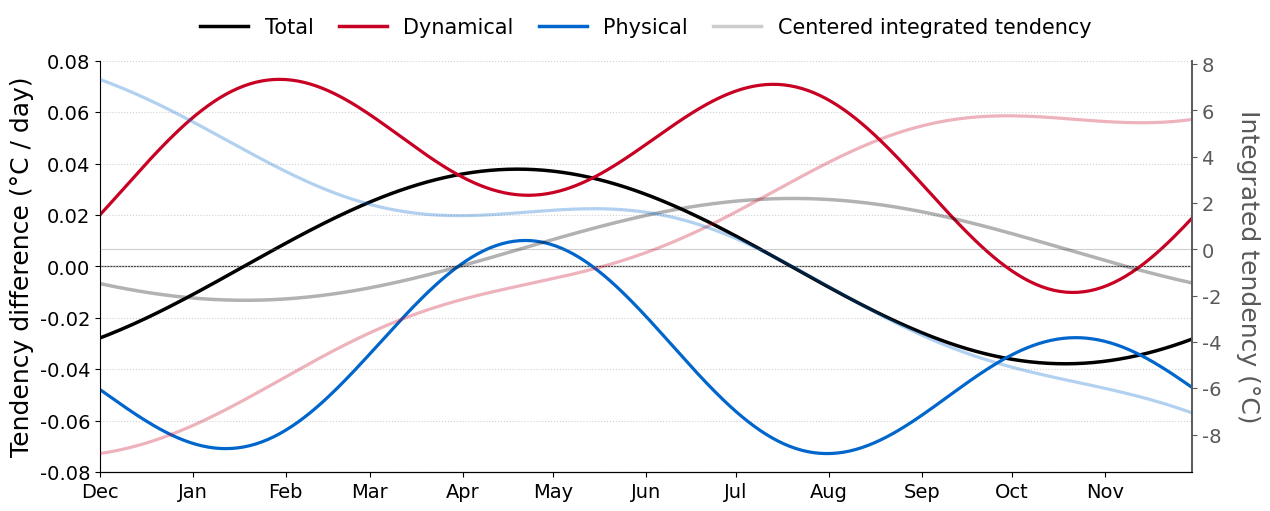

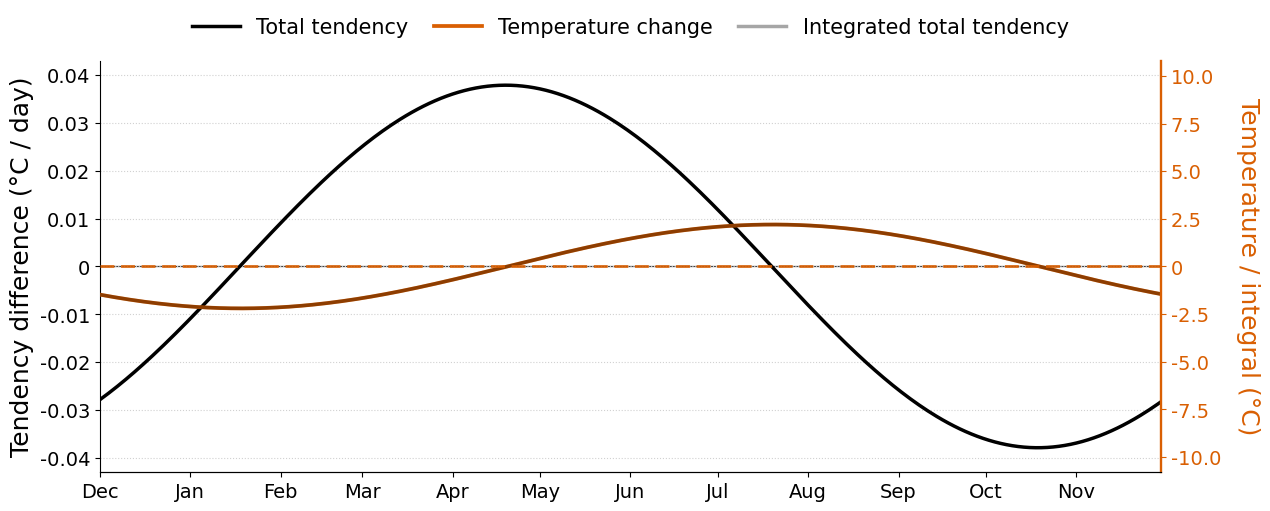

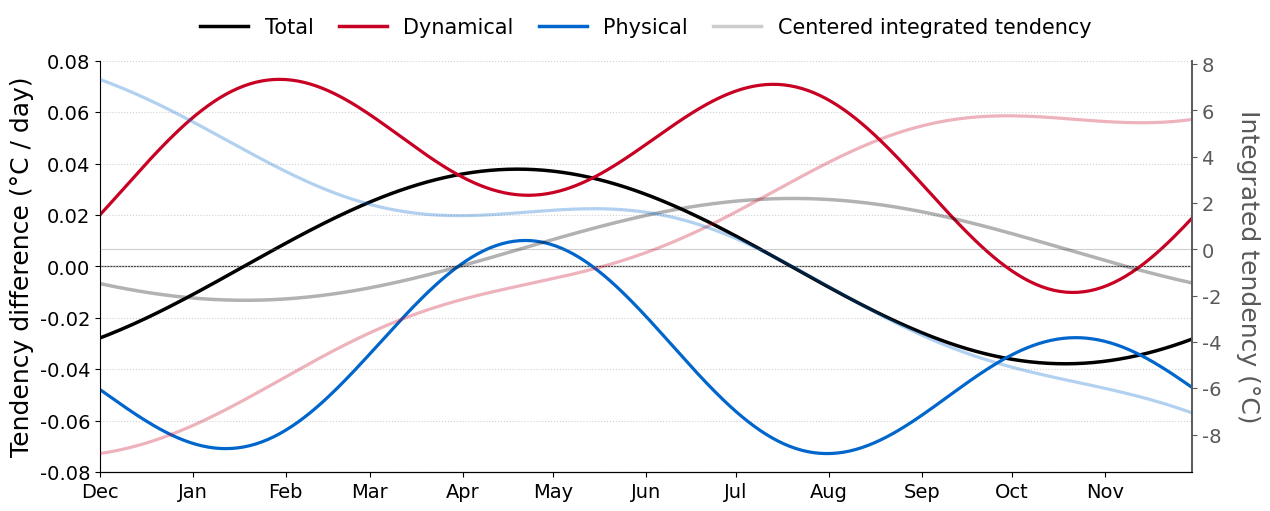

In [142]:
# %%
# Calendar-day differences between P2 and P1.
# The derivation is shown step by step. Each step has:
# 1) temperature with total tendency, and 2) total tendency with processes.

delta_T = T_P2 - T_P1
delta_D = D_P2 - D_P1
processes = ['dyntot', 'phystot']

delta_D_process = {
    process: D_process_P2[process] - D_process_P1[process]
    for process in processes
}
np.testing.assert_allclose(delta_D_process['dyntot'] + delta_D_process['phystot'], delta_D, atol=1e-12)

# Integrated tendency differences. Centering removes the arbitrary integration constant.
delta_D_int = np.r_[0, np.cumsum(delta_D[:-1])]
delta_D_int_centered = delta_D_int - delta_D_int.mean()
delta_T_centered = delta_T - delta_T.mean()

delta_D_process_int = {
    process: np.r_[0, np.cumsum(delta_D_process[process][:-1])]
    for process in processes
}
delta_D_process_int_centered = {
    process: delta_D_process_int[process] - delta_D_process_int[process].mean()
    for process in processes
}
np.testing.assert_allclose(
    delta_D_process_int['dyntot'] + delta_D_process_int['phystot'],
    delta_D_int,
    atol=1e-12,
)
np.testing.assert_allclose(
    delta_D_process_int_centered['dyntot'] + delta_D_process_int_centered['phystot'],
    delta_D_int_centered,
    atol=1e-12,
)

d_ticks = np.array([-0.04, -0.03, -0.02, -0.01, 0.00, 0.01, 0.02, 0.03, 0.04])
t_ticks = np.array([-10.0, -7.5, -5.0, -2.5, 0.0, 2.5, 5.0, 7.5, 10.0])
dlim = 0.043
tlim = 10.8


def plot_total_temperature_difference(delta_T_plot, integral_plot=None, temp_mean_line=None):
    fig, ax_tend = plt.subplots(figsize=(12.8, 5.2))
    ax_temp = ax_tend.twinx()

    ax_tend.plot(days, delta_D, color=PROCESS_COLORS['tendtot'], lw=2.5, label='Total tendency')
    ax_temp.plot(days, delta_T_plot, color=TEMP_COLOR, lw=2.7, label='Temperature change')

    if integral_plot is not None:
        ax_temp.plot(
            days, integral_plot,
            color=PROCESS_COLORS['tendtot'], lw=2.5, alpha=0.35,
            label='Integrated total tendency',
        )

    if temp_mean_line is not None:
        ax_temp.axhline(
            temp_mean_line,
            color=TEMP_COLOR,
            lw=2.0,
            ls='--',
            dashes=(5.0, 2.4),
            alpha=0.9,
            zorder=2,
        )

    ax_tend.axhline(0, color='0.25', lw=0.9, zorder=1)
    ax_tend.grid(axis='y', color='0.82', lw=0.8, linestyle=':', zorder=0)
    ax_tend.set_xlim(days[0], days[-1])
    ax_tend.set_xticks(month_ticks)
    ax_tend.set_xticklabels(month_labels, fontsize=12)
    ax_tend.set_ylim(-dlim, dlim)
    ax_temp.set_ylim(-tlim, tlim)
    ax_tend.set_yticks(d_ticks)
    ax_temp.set_yticks(t_ticks)
    ax_tend.set_yticklabels(['0' if np.isclose(tick, 0) else f'{tick:.2f}' for tick in d_ticks])
    ax_temp.set_yticklabels(['0' if np.isclose(tick, 0) else f'{tick:.1f}' for tick in t_ticks])

    ax_tend.set_ylabel('Tendency difference (°C / day)', fontsize=18, color='black')
    ax_temp.set_ylabel('Temperature / integral (°C)', fontsize=18, color=TEMP_COLOR, rotation=270, labelpad=28)
    ax_tend.tick_params(axis='y', labelsize=14, colors='black')
    ax_temp.tick_params(axis='y', labelsize=14, colors=TEMP_COLOR)
    ax_tend.tick_params(axis='x', labelsize=14)

    for ax in [ax_tend, ax_temp]:
        ax.spines['top'].set_visible(False)
    ax_tend.spines['right'].set_visible(False)
    ax_temp.spines['left'].set_visible(False)
    ax_temp.spines['right'].set_color(TEMP_COLOR)
    ax_temp.spines['right'].set_linewidth(1.7)

    handles = [*ax_tend.get_legend_handles_labels()[0], *ax_temp.get_legend_handles_labels()[0]]
    labels = [*ax_tend.get_legend_handles_labels()[1], *ax_temp.get_legend_handles_labels()[1]]
    ax_tend.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(handles),
        frameon=False,
        fontsize=15,
        columnspacing=1.2,
        handlelength=2.3,
    )

    plt.tight_layout()
    plt.show()


def plot_process_difference(integral_plot=None, process_integrals=None, integral_label='Integrated tendency'):
    fig, ax_tend = plt.subplots(figsize=(12.8, 5.2))
    ax_int = ax_tend.twinx() if integral_plot is not None else None

    ax_tend.plot(days, delta_D, color=PROCESS_COLORS['tendtot'], lw=2.5, label=PROCESS_LABELS['tendtot'])
    for process in processes:
        ax_tend.plot(
            days, delta_D_process[process],
            color=PROCESS_COLORS[process], lw=2.3, label=PROCESS_LABELS[process],
        )

    if integral_plot is not None:
        ax_int.plot(days, integral_plot, color=PROCESS_COLORS['tendtot'], lw=2.5, alpha=0.30)
        for process in processes:
            ax_int.plot(
                days, process_integrals[process],
                color=PROCESS_COLORS[process], lw=2.3, alpha=0.30,
            )
        ax_int.axhline(0, color='0.45', lw=0.8, alpha=0.35, zorder=1)
        ax_int.set_ylabel('Integrated tendency (°C)', fontsize=18, color='0.35', rotation=270, labelpad=28)
        ax_int.tick_params(axis='y', labelsize=14, colors='0.35')
        ax_int.spines['top'].set_visible(False)
        ax_int.spines['left'].set_visible(False)
        ax_int.spines['right'].set_color('0.35')
        ax_int.spines['right'].set_linewidth(1.4)

    ax_tend.axhline(0, color='0.25', lw=0.9, zorder=1)
    ax_tend.grid(axis='y', color='0.82', lw=0.8, linestyle=':', zorder=0)
    ax_tend.set_xlim(days[0], days[-1])
    ax_tend.set_xticks(month_ticks)
    ax_tend.set_xticklabels(month_labels, fontsize=12)
    ax_tend.set_ylabel('Tendency difference (°C / day)', fontsize=18)
    ax_tend.tick_params(axis='both', labelsize=14)
    ax_tend.spines['top'].set_visible(False)
    ax_tend.spines['right'].set_visible(False)

    handles = [
        plt.Line2D([0], [0], color=PROCESS_COLORS['tendtot'], lw=2.5, label=PROCESS_LABELS['tendtot']),
        plt.Line2D([0], [0], color=PROCESS_COLORS['dyntot'], lw=2.5, label=PROCESS_LABELS['dyntot']),
        plt.Line2D([0], [0], color=PROCESS_COLORS['phystot'], lw=2.5, label=PROCESS_LABELS['phystot']),
    ]
    if integral_plot is not None:
        handles.append(plt.Line2D([0], [0], color='0.35', lw=2.5, alpha=0.30, label=integral_label))

    ax_tend.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(handles),
        frameon=False,
        fontsize=15,
        columnspacing=1.2,
        handlelength=2.3,
    )

    plt.tight_layout()
    plt.show()


def plot_difference_pair(delta_T_plot, integral_plot=None, process_integrals=None,
                         temp_mean_line=None, integral_label='Integrated tendency'):
    plot_total_temperature_difference(delta_T_plot, integral_plot, temp_mean_line)
    plot_process_difference(integral_plot, process_integrals, integral_label)


# 1) Raw temperature and total/process tendency differences.
plot_difference_pair(
    delta_T_plot=delta_T,
    integral_plot=None,
    process_integrals=None,
    temp_mean_line=delta_T.mean(),
)

# 2) Add the integrated tendencies, starting from zero.
plot_difference_pair(
    delta_T_plot=delta_T,
    integral_plot=delta_D_int,
    process_integrals=delta_D_process_int,
    temp_mean_line=delta_T.mean(),
    integral_label='Integrated tendency',
)

# 3) Center the integrated tendencies.
plot_difference_pair(
    delta_T_plot=delta_T,
    integral_plot=delta_D_int_centered,
    process_integrals=delta_D_process_int_centered,
    temp_mean_line=delta_T.mean(),
    integral_label='Centered integrated tendency',
)

# 4) Center the temperature change as well.
plot_difference_pair(
    delta_T_plot=delta_T_centered,
    integral_plot=delta_D_int_centered,
    process_integrals=delta_D_process_int_centered,
    temp_mean_line=0.0,
    integral_label='Centered integrated tendency',
)


# Toying with the toy model

In [143]:
# Period split
L = n_years // 2

periods = {
    'Ptrend':  [year_labels[0], year_labels[-1]],
    'PtrendL': [year_labels[0], year_labels[L - 1]],
    'PtrendR': [year_labels[L], year_labels[-1]],
}

left_sel = slice(0, L)
right_sel = slice(L, n_years)

In [144]:
# Calendar-day climatologies
clim_temp = {
    'PtrendL': T_y_d[left_sel].mean(axis=0),
    'PtrendR': T_y_d[right_sel].mean(axis=0),
}

clim_tend = {
    'PtrendL': D_y_d[left_sel].mean(axis=0),
    'PtrendR': D_y_d[right_sel].mean(axis=0),
}

clim_temp_ref = {
    'PtrendL': T_ref_y_d[left_sel].mean(axis=0),
    'PtrendR': T_ref_y_d[right_sel].mean(axis=0),
}

clim_tend_ref = {
    'PtrendL': D_ref_y_d[left_sel].mean(axis=0),
    'PtrendR': D_ref_y_d[right_sel].mean(axis=0),
}

# True Trends

In [145]:
delta_T_d = clim_temp['PtrendR'] - clim_temp['PtrendL']
delta_D_d = clim_tend['PtrendR'] - clim_tend['PtrendL']

# True annual trend
mu_true = delta_T_d.mean()
tau_true = mu_true / L

# True relative trend
Theta_true_d = delta_T_d - mu_true
theta_true_d = Theta_true_d / L

# Seasonal relative trends
thetaS_true = {
    season: theta_true_d[mask].mean()
    for season, mask in season_days.items()
}

print(f'Absolute warming = {mu_true:.3f} °C')
print(f'Annual trend = {tau_true:.4f} °C / year')
print(f'Annual mean warming rate from a(y,d) = {a_y_d.mean():.4f} °C / year')

Absolute warming = 6.600 °C
Annual trend = 0.3000 °C / year
Annual mean warming rate from a(y,d) = 0.3000 °C / year


# Relative Trends

In [146]:
def cumsum_from_zero(da, dim='month_day'):
    return da.shift({dim: 1}, fill_value=0).cumsum(dim)

# Relative trend from tendencies
delta_T_d = clim_temp['PtrendR'] - clim_temp['PtrendL']
delta_D_d = clim_tend['PtrendR'] - clim_tend['PtrendL']

B_from_T = delta_T_d - delta_T_d[0]
B_from_D = np.concatenate([[0], np.cumsum(delta_D_d[:-1])])

theta_from_D = (B_from_D - B_from_D.mean())/L
thetaS_from_D = {
    season: theta_from_D[mask].mean()
    for season, mask in season_days.items()
}

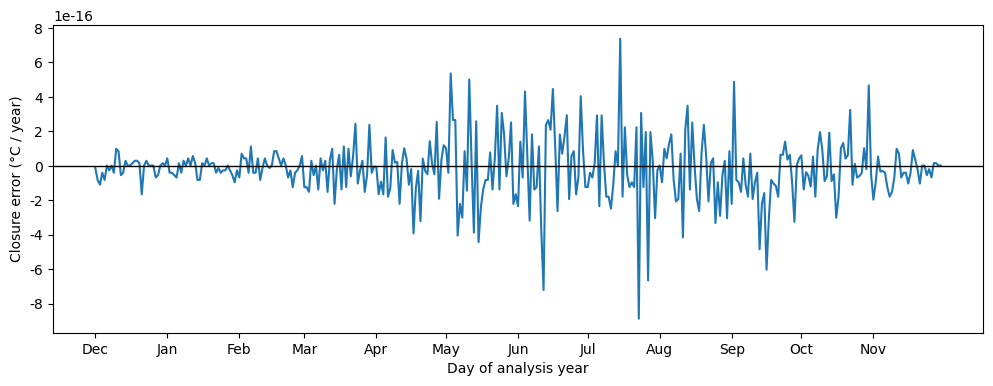

Seasonal Closure DJF: -2.7756e-17 °C / year
Seasonal Closure MAM: -2.2551e-17 °C / year
Seasonal Closure JJA: -1.3878e-17 °C / year
Seasonal Closure SON: -4.0766e-17 °C / year


In [147]:
# Useful closure checks
closure_theta = theta_from_D - theta_true_d

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days, closure_theta)
ax.axhline(0, color='black', lw=1.0)
ax.set_ylabel('Closure error (°C / year)')
ax.set_xlabel('Day of analysis year')
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels)
plt.show()

closureS = {
    season: thetaS_from_D[season] - thetaS_true[season]
    for season in season_days
}

for season in season_days:
    print(f'Seasonal Closure {season}: {closureS[season]:.4e} °C / year')

# Annual trends

In [148]:
# Construct yearly tendencies
w_day = (days_per_year - (days + 1)) / days_per_year
Y_y_d = (1 - w_day)*D_y_d[:-1] + w_day*D_y_d[1:]
Y_y = Y_y_d.sum(axis=1)

# For reference
Y_ref_y_d = (1 - w_day)*D_ref_y_d[:-1] + w_day*D_ref_y_d[1:]
Y_ref_y = Y_ref_y_d.sum(axis=1)

# Check closure
T_year = T_y_d.mean(axis=1)
yearly_closure = Y_y - (T_year[1:] - T_year[:-1])
yearly_closure

array([ 0.00000000e+00,  5.32907052e-15,  0.00000000e+00,  3.55271368e-15,
       -5.32907052e-15,  0.00000000e+00,  3.55271368e-15, -3.55271368e-15,
        5.32907052e-15,  0.00000000e+00, -1.77635684e-15, -1.77635684e-15,
        0.00000000e+00,  1.06581410e-14, -5.32907052e-15,  0.00000000e+00,
        1.77635684e-15, -1.77635684e-15, -5.32907052e-15,  3.55271368e-15,
       -7.10542736e-15, -3.55271368e-15, -3.55271368e-15,  3.55271368e-15,
        0.00000000e+00,  0.00000000e+00, -3.55271368e-15,  0.00000000e+00,
        0.00000000e+00,  3.55271368e-15, -3.55271368e-15,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  3.55271368e-15,
        3.55271368e-15,  7.10542736e-15, -3.55271368e-15, -7.10542736e-15,
       -3.55271368e-15, -3.55271368e-15,  7.10542736e-15])

In [149]:
# Construct period tendencies
w_year = (L - (np.arange(L) + 1)) / L

Y_left_d = Y_y_d[:L]
Y_right_d = np.zeros_like(Y_left_d)
Y_right_d[:-1] = Y_y_d[L:]

mu_d = ((1 - w_year[:, None])*Y_left_d + w_year[:, None]*Y_right_d).sum(axis=0)
tau_d = mu_d / L

tau = tau_d.sum()

tauS = {
    season: tau_d[mask].sum()
    for season, mask in season_days.items()
}

In [150]:
# For reference
Y_ref_left_d = Y_ref_y_d[:L]
Y_ref_right_d = np.zeros_like(Y_ref_left_d)
Y_ref_right_d[:-1] = Y_ref_y_d[L:]

mu_ref_d = ((1 - w_year[:, None]) * Y_ref_left_d + w_year[:, None] * Y_ref_right_d).sum(axis=0)
tau_ref_d = mu_ref_d / L

tau_ref = tau_ref_d.sum()

tauS_ref = {
    season: tau_ref_d[mask].sum()
    for season, mask in season_days.items()
}

# Compared to reference
tau_hat_d = tau_d - tau_ref_d

tau_hat = tau_hat_d.sum()

tauS_hat = {
    season: tau_hat_d[mask].sum()
    for season, mask in season_days.items()
}

In [151]:
# Process tendency decomposition
processes = ['phystot', 'dyntot']

clim_tend_process = {
    process: {
        'PtrendL': D_process_y_d[process][left_sel].mean(axis=0),
        'PtrendR': D_process_y_d[process][right_sel].mean(axis=0),
    }
    for process in processes
}

delta_D_process_d = {
    process: clim_tend_process[process]['PtrendR'] - clim_tend_process[process]['PtrendL']
    for process in processes
}

B_process_from_D = {
    process: np.concatenate([[0], np.cumsum(delta_D_process_d[process][:-1])])
    for process in processes
}

theta_process_d = {
    process: (B_process_from_D[process] - B_process_from_D[process].mean()) / L
    for process in processes
}

thetaS_process = {
    process: {
        season: theta_process_d[process][mask].mean()
        for season, mask in season_days.items()
    }
    for process in processes
}

Y_process_y_d = {
    process: (1 - w_day) * D_process_y_d[process][:-1] + w_day * D_process_y_d[process][1:]
    for process in processes
}

tau_process_d = {}
for process in processes:
    Y_process_left_d = Y_process_y_d[process][:L]
    Y_process_right_d = np.zeros_like(Y_process_left_d)
    Y_process_right_d[:-1] = Y_process_y_d[process][L:]

    mu_process_d = (
        (1 - w_year[:, None]) * Y_process_left_d
        + w_year[:, None] * Y_process_right_d
    ).sum(axis=0)
    tau_process_d[process] = mu_process_d / L

tau_process = {
    process: tau_process_d[process].sum()
    for process in processes
}

tauS_process = {
    process: {
        season: tau_process_d[process][mask].sum()
        for season, mask in season_days.items()
    }
    for process in processes
}

np.testing.assert_allclose(D_phystot_y_d + D_dyntot_y_d, D_y_d, atol=1e-12)
np.testing.assert_allclose(
    theta_process_d['phystot'] + theta_process_d['dyntot'],
    theta_from_D,
    atol=1e-12,
)
np.testing.assert_allclose(
    tau_process_d['phystot'] + tau_process_d['dyntot'],
    tau_d,
    atol=1e-12,
)

process_climatology = {
    process: D_process_y_d[process].mean(axis=0)
    for process in ['tendtot', *processes]
}

process_seasonal_mean = {
    process: {
        season: process_climatology[process][mask].mean()
        for season, mask in season_days.items()
    }
    for process in process_climatology
}

for process in processes:
    print(f'{PROCESS_LABELS[process]}: annual mean tendency = {process_climatology[process].mean():+.4f} °C / day')
    for season in season_days:
        print(f'  {season}: {process_seasonal_mean[process][season]:+.4f} °C / day')


Physical: annual mean tendency = +0.0208 °C / day
  DJF: -0.2632 °C / day
  MAM: +0.3768 °C / day
  JJA: +0.2629 °C / day
  SON: -0.3029 °C / day
Dynamical: annual mean tendency = -0.0202 °C / day
  DJF: +0.2989 °C / day
  MAM: -0.1918 °C / day
  JJA: -0.2983 °C / day
  SON: +0.1189 °C / day


In [152]:
# Useful closure checks
period_closure = tau_d.sum() - tau_true
reference_closure = tau_ref_d.sum()
hat_closure = tau_hat_d.sum() - tau_true
print(f'period closure error = {period_closure:.3e} °C / year')
print(f'reference sum = {reference_closure:.3e} °C / year')
print(f'reference-relative closure error = {hat_closure:.3e} °C / year')

period closure error = 4.274e-15 °C / year
reference sum = 3.553e-15 °C / year
reference-relative closure error = 7.216e-16 °C / year


# Total Trend

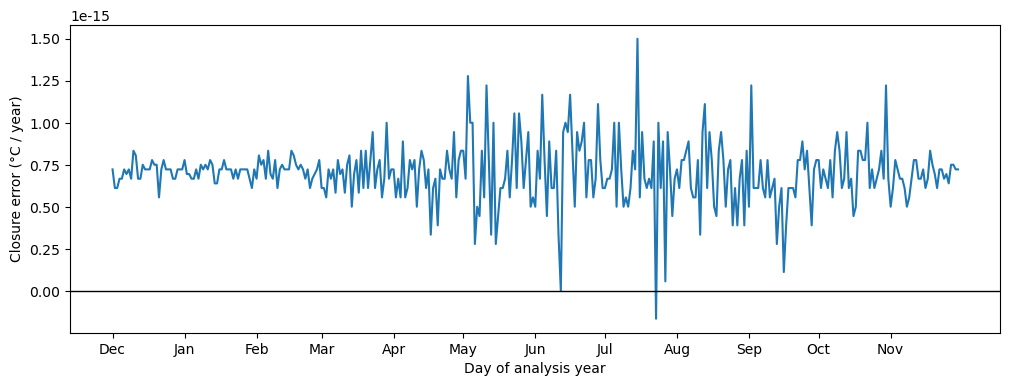

Total Trend Seasonal Closure DJF: 7.2164e-16 °C / year
Total Trend Seasonal Closure MAM: 7.2164e-16 °C / year
Total Trend Seasonal Closure JJA: 6.6613e-16 °C / year
Total Trend Seasonal Closure SON: 6.6613e-16 °C / year


In [153]:
# Total trend = annual trend + relative trend
total_true_d = tau_true + theta_true_d
total_from_D = tau_hat + theta_from_D

# Useful closure checks
closure_total = total_from_D - total_true_d

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days, closure_total)
ax.axhline(0, color='black', lw=1.0)
ax.set_ylabel('Closure error (°C / year)')
ax.set_xlabel('Day of analysis year')
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels)
plt.show()

totalS_true = {
    season: tau_true + thetaS_true[season]
    for season in season_days
}

totalS_from_D = {
    season: tau_hat_d.sum() + thetaS_from_D[season]
    for season in season_days
}

closureS_total = {
    season: totalS_from_D[season] - totalS_true[season]
    for season in season_days
}

for season in season_days:
    print(f'Total Trend Seasonal Closure {season}: {closureS_total[season]:.4e} °C / year')